In [1]:
# import the usual suspects
import os
import rdkit
from rdkit import Chem
import pandas as pd
from time import time
import numpy as np
import sys
sys.path.append('..')
import matplotlib.pyplot as plt

## import dataset ##

In [2]:
full_set = True

if full_set:
    csv_file = "../../tests/data/SLC6A4_active_excape_export.csv"
    if not os.path.exists(csv_file):
        import urllib.request

        url = "https://ndownloader.figshare.com/files/25747817"
        urllib.request.urlretrieve(url, csv_file)
else:
    csv_file = "../../tests/data/SLC6A4_active_excapedb_subset.csv"

data = pd.read_csv(csv_file) 

In [3]:
data.head()

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
0,AZMKBJHIXZCVNL-BXKDBHETNA-N,44590643,6532,A,5.68382,pubchem,393260,9606,SLC6A4,4061,FC1=CC([C@@H]2O[C@H](CC2)CN)=C(OC)C=C1
1,AZMKBJHIXZCVNL-UHFFFAOYNA-N,11492305,6532,A,5.16210,pubchem,393258,9606,SLC6A4,4061,FC1=CC(C2OC(CC2)CN)=C(OC)C=C1
2,AZOHUEDNMOIDOC-GETDIYNLNA-N,44419340,6532,A,6.66354,pubchem,276059,9606,SLC6A4,4061,FC1=CC=C(C[C@H]2C[C@@H](N(CC2)CC=C)CCCNC(=O)NC...
3,AZSKJKSQZWHDOK-VJSLDGLSNA-N,CHEMBL1080745,6532,A,6.96000,chembl20,617082,9606,SLC6A4,4061,C=1C=C(C=CC1)C2=CC(=C(N2CC(C)C)C)C(NCCCN3CCN(C...
4,AZTPZTRJVCAAMX-UHFFFAOYNA-N,CHEMBL578346,6532,A,8.00000,chembl20,596934,9606,SLC6A4,4061,C1=CC=C2C(=C1)C=C(C(N(C3CCNCC3)C4CCC4)=O)C=C2


In [4]:
print(len(data))

7228


## Murcko Scaffold Transformation ###

In [5]:
from rdkit.Chem.Scaffolds import MurckoScaffold # for comparison
from sklearn.pipeline import Pipeline
from conversions import SmilesToMolTransformer, MolToScaffoldTransformer, MurckoScaffoldGenerator

With MolToScaffoldTransformer, we are implementing a generic transformer that reads RDKit mol objects and applies a user-defined scaffold. Currently, we are only supporting Murcko scaffolds, but designed scikit-mol such that it is rather straightforward to add your desired scaffold generator. 

  The MurckoScaffoldGenerator has two important options:


   * `include_chirality`: If set to True, stereocenters in the scaffold will be preserved. This is important if the 3D arrangement of your core structure is critical for its function. If False, all stereochemical information is removed.
       * Example: A chiral scaffold might have a SMILES of C1C[C@H](C)CC1, while its non-chiral version would be C1CC(C)CC1.


   * `make_generic`: If set to True, it converts all atoms in the scaffold to generic carbon atoms and all bonds to single bonds. This is useful for finding more abstract structural relationships, where you only care about the graph connectivity of the ring systems,
     not the specific elements or bond types.

  What About Molecules Without Rings?

  A Murcko scaffold is only defined for molecules that contain at least one ring. What happens if you have an acyclic molecule like ethanol (CCO) in your dataset? The pipeline handles this automatically and will identify that no scaffold can be generated. It will produce an InvalidMol object for that entry. This ensures that your workflow doesn't crash and you can easily filter out these cases later if needed.

In [6]:
pipeline = Pipeline([('mol_transformer', SmilesToMolTransformer(safe_inference_mode = True)), ('scaffold_transformer', 
                    MolToScaffoldTransformer(safe_inference_mode=True, scaffold_generator=MurckoScaffoldGenerator(include_chirality=False, make_generic=False)))])

In [7]:
from scikit_mol.core import InvalidMol
murcko_example = pipeline.transform(['CCO'])
assert type(murcko_example[0][0]) == InvalidMol
assert murcko_example[0][0].error == 'Scaffold generation resulted in an empty molecule.'
print(murcko_example[0][0])

InvalidMol('MolToScaffoldTransformer(safe_inference_mode=True,
                         scaffold_generator=MurckoScaffoldGenerator())', error='Scaffold generation resulted in an empty molecule.')


In [8]:
murcko = pipeline.transform(data['SMILES'])

In [9]:
# The above transformation can be equivalently generated by
murcko_rdkit = [None] * len(data['SMILES'])
for i, smiles in enumerate(data['SMILES']):
    murcko_rdkit[i] = MurckoScaffold.MurckoScaffoldSmiles(smiles = smiles, includeChirality = False)

In [11]:
## Now more explicit comparison ##

In [12]:
pipeline = Pipeline([('mol_transformer', SmilesToMolTransformer(safe_inference_mode = True)), 
                     ('scaffold_transformer', MolToScaffoldTransformer(safe_inference_mode=True, 
                                                                       scaffold_generator=MurckoScaffoldGenerator(include_chirality=False, 
                                                                                                                  make_generic=False)))])
murcko = pipeline.transform(data['SMILES'])
for smiles, murcko_scaffold in zip(data['SMILES'], murcko):
    assert MurckoScaffold.MurckoScaffoldSmiles(smiles = smiles, includeChirality = False) == Chem.MolToSmiles(murcko_scaffold[0])

In [13]:
pipeline = Pipeline([('mol_transformer', SmilesToMolTransformer(safe_inference_mode = True)), 
                     ('scaffold_transformer', MolToScaffoldTransformer(safe_inference_mode=True, 
                                                                       scaffold_generator=MurckoScaffoldGenerator(include_chirality=True, 
                                                                                                                  make_generic=False)))])
murcko = pipeline.transform(data['SMILES'])
for smiles, murcko_scaffold in zip(data['SMILES'], murcko):
    assert MurckoScaffold.MurckoScaffoldSmiles(smiles = smiles, includeChirality = True) == Chem.MolToSmiles(murcko_scaffold[0])

Both assertions passed, seems like we are handling the chirality correctly.

## StratifiedGroupShuffleSplit ##

With the StratifiedGroupShuffleSplit, we are providing a scikit-learn cross-validator that satisfies the following properties:
    
1- Same group does not appear in both training and test sets,
2- train/test split is done such that the class labels (y) have the same distribution in both sets and the full dataset
3- For each new split, a fresh random sampling of the data is performed to form a single train and test set. The splits are independent of each other and can overlap.

```python
StratifiedGroupShuffleSplit.__init__( 
    self,
    n_splits: int = 5,
    *,
    test_size: float = 0.2,
    train_size: float = None,
    random_state: int = None,
    sample_weighted: bool = False,
    suppress_warnings: bool = False,
)
```

You can define a test and train size in the same way as you do in scikit-learn: a float value will mean a fraction (test_size = 0.2 -> 20% of the data will be used for testing), while an int value will mean a number of samples (test_size = 10 -> 10 samples will be used for testing). 

Our implementation of the `StratifiedGroupShuffleSplit` uses a greedy search algorithm to find the best possible split that satisfies the above properties. One key point of the algorithm is that it will create a list of groups that can be properly fit into the test set, and then start placing these groups into the test set by randomly selecting them. `sample_weighted=True` will make the selection use the number of samples in each group as a weight, meaning that groups with more samples will be prioritized. 

Some important caveats are, 

1- Due to the nature of the optimization problem, we cannot guarantee that the returned `test_size` will be the same as the requested `test_size`. If the requested and returned test set sizes differ by larget than 5%, you will get a warning (provided `suppress_warnings=False`)
2- It is possible that the dataset contains groups that are too large to fit into your requested `test_size`. In this case, you will get a warning (provided `suppress_warnings=False`)

In [19]:
# helper script to make our lives a bit easier and cleaner
def print_report(splitter, x, y, groups):
    
    for i, (train_index, test_index) in enumerate(splitter.split(x, y, groups)):
        
        y_train_counts, y_test_counts, groups_train_counts, groups_test_counts = (
        np.unique(y[train_index], return_counts=True),
        np.unique(y[test_index], return_counts=True),
        np.unique(groups[train_index], return_counts=True),
        np.unique(groups[test_index], return_counts=True)
        )
        
        print(f"Split: {i}")
        print(f"Train y and their counts: {y_train_counts}")
        print(f"Test y and their counts: {y_test_counts}")
        print(f"Train set class label distribution: {y_train_counts[1]/len(y[train_index])}")
        print(f"Test set class label distribution: {y_test_counts[1]/len(y[test_index])}")
        print(f"Train groups and their counts:: {groups_train_counts}")
        print(f"Test groups and their counts: {groups_test_counts}")
        print(f"Train size: {len(y[train_index])}")
        print(f"Test size: {len(y[test_index])}")
        print(f"Overlapping groups in train and test splits: {len(set(groups[train_index]).intersection(set(groups[test_index])))}\n")


In [20]:
# Let's create a dummy balanced dataset
x = np.random.rand(1000)
y_balanced = np.random.randint(0,3,1000)
groups_balanced = np.random.randint(0,10,1000)

In [21]:
# Let's create a dummy imbalanced dataset
x = np.random.rand(1000)
y_imbalanced = np.random.randint(0,3,1000)
groups = np.random.randint(0,2,1000)
y_imbalanced[0:900] = 0
np.random.shuffle(y_imbalanced)
groups[0:850] = 1
groups_imbalanced = groups.copy()

In [22]:
# Groups are splitted, i.e. the same group does not occur both in the test and train split
from sklearn.model_selection import GroupShuffleSplit
sss = GroupShuffleSplit(n_splits=2, test_size=0.2)
print(f"Unique y and their counts in the full dataset: {np.unique(y_balanced, return_counts=True)}")
print(f"Unique groups and their counts in the full dataset: {np.unique(groups_balanced, return_counts=True)}")
print_report(sss, x, y_balanced, groups_balanced)

Unique y and their counts in the full dataset: (array([0, 1, 2]), array([349, 331, 320]))
Unique groups and their counts in the full dataset: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 79, 104, 114, 105,  84, 105,  91, 112,  99, 107]))
Split: 0
Train y and their counts: (array([0, 1, 2]), array([265, 275, 256]))
Test y and their counts: (array([0, 1, 2]), array([84, 56, 64]))
Train set class label distribution: [0.33291457 0.34547739 0.32160804]
Test set class label distribution: [0.41176471 0.2745098  0.31372549]
Train groups and their counts:: (array([0, 1, 2, 3, 4, 6, 7, 9]), array([ 79, 104, 114, 105,  84,  91, 112, 107]))
Test groups and their counts: (array([5, 8]), array([105,  99]))
Train size: 796
Test size: 204
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([272, 272, 247]))
Test y and their counts: (array([0, 1, 2]), array([77, 59, 73]))
Train set class label distribution: [0.34386852 0.34386852 0.31226296]
Te

In [23]:
# When we have a dataset with a strong class imbalance (NOTE: Group labels are still balanced)
# Groups are splitted, i.e. the same group does not occur both in the test and train split
# But the stratification is not guaranteed, i.e. class distributions (y-labels) in the test and train sets are not the same as in the full dataset
# In your dataset if one class label is occurring much more often than the other class labels (imbalanced dataset), without stratification 
# you are risking of not having the under-represented cl\asses in the test set
from sklearn.model_selection import GroupShuffleSplit
sss = GroupShuffleSplit(n_splits=2, test_size=0.2, random_state = 42)
print(f"Unique y and their counts in the full dataset: {np.unique(y_imbalanced, return_counts=True)}")
print(f"Unique groups and their counts in the full dataset: {np.unique(groups, return_counts=True)}")


print_report(sss, x, y_imbalanced, groups)

Unique y and their counts in the full dataset: (array([0, 1, 2]), array([930,  37,  33]))
Unique groups and their counts in the full dataset: (array([0, 1]), array([ 75, 925]))
Split: 0
Train y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Test y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Train set class label distribution: [0.94666667 0.04       0.01333333]
Test set class label distribution: [0.92864865 0.03675676 0.03459459]
Train groups and their counts:: (array([0]), array([75]))
Test groups and their counts: (array([1]), array([925]))
Train size: 75
Test size: 925
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Test y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Train set class label distribution: [0.92864865 0.03675676 0.03459459]
Test set class label distribution: [0.94666667 0.04       0.01333333]
Train groups and their counts:: (array([1]), array([925]))
Tes

In [24]:
# When we have a dataset with a strong class imbalance and strong group imbalance:
# Groups are splitted, i.e. the same group does not occur both in the test and train split
# But the stratification is not guaranteed, i.e. class distributions (y-labels) in the test and train sets are not the same as in the full dataset
# In your dataset if one class label is occurring much more often than the other class labels (imbalanced dataset), without stratification 
# you are risking of not having the under-represented classes in the test set
from sklearn.model_selection import GroupShuffleSplit
sss = GroupShuffleSplit(n_splits=2, test_size=0.2, random_state = 42)
print(f"Unique y and their counts in the full dataset: {np.unique(y_imbalanced, return_counts=True)}")
print(f"Unique groups and their counts in the full dataset: {np.unique(groups_imbalanced, return_counts=True)}")

print_report(sss, x, y_imbalanced , groups_imbalanced)

Unique y and their counts in the full dataset: (array([0, 1, 2]), array([930,  37,  33]))
Unique groups and their counts in the full dataset: (array([0, 1]), array([ 75, 925]))
Split: 0
Train y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Test y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Train set class label distribution: [0.94666667 0.04       0.01333333]
Test set class label distribution: [0.92864865 0.03675676 0.03459459]
Train groups and their counts:: (array([0]), array([75]))
Test groups and their counts: (array([1]), array([925]))
Train size: 75
Test size: 925
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Test y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Train set class label distribution: [0.92864865 0.03675676 0.03459459]
Test set class label distribution: [0.94666667 0.04       0.01333333]
Train groups and their counts:: (array([1]), array([925]))
Tes

In [25]:
# If you use GroupKFold on an imbalanced dataset, you will be able to separate the groups but your splits won't be stratified

from sklearn.model_selection import GroupKFold
sss = GroupKFold(n_splits=3, shuffle=True, random_state=None)
groups_counts = np.unique(groups, return_counts=True)
print(groups_counts)
print(f"Full dataset class label distribution: {np.unique(y_imbalanced, return_counts=True)[1]/len(y_imbalanced)}\n")

print_report(sss, x, y_imbalanced, groups_balanced)

(array([0, 1]), array([ 75, 925]))
Full dataset class label distribution: [0.93  0.037 0.033]

Split: 0
Train y and their counts: (array([0, 1, 2]), array([587,  20,  19]))
Test y and their counts: (array([0, 1, 2]), array([343,  17,  14]))
Train set class label distribution: [0.93769968 0.03194888 0.03035144]
Test set class label distribution: [0.9171123  0.04545455 0.03743316]
Train groups and their counts:: (array([1, 2, 4, 5, 7, 9]), array([104, 114,  84, 105, 112, 107]))
Test groups and their counts: (array([0, 3, 6, 8]), array([ 79, 105,  91,  99]))
Train size: 626
Test size: 374
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([643,  24,  23]))
Test y and their counts: (array([0, 1, 2]), array([287,  13,  10]))
Train set class label distribution: [0.93188406 0.03478261 0.03333333]
Test set class label distribution: [0.92580645 0.04193548 0.03225806]
Train groups and their counts:: (array([0, 1, 3, 5, 6, 8, 9]), array([ 7

In [26]:
# To ensure both groups are separated and the class labels are stratified, you can use StratifiedGroupKFold. Note that you cannot define a test set size here

from sklearn.model_selection import StratifiedGroupKFold
sss = StratifiedGroupKFold(n_splits=3)
groups_counts = np.unique(groups, return_counts=True)
print(groups_counts)
print_report(sss, x, y_balanced, groups_balanced)

(array([0, 1]), array([ 75, 925]))
Split: 0
Train y and their counts: (array([0, 1, 2]), array([240, 242, 224]))
Test y and their counts: (array([0, 1, 2]), array([109,  89,  96]))
Train set class label distribution: [0.33994334 0.3427762  0.31728045]
Test set class label distribution: [0.3707483  0.30272109 0.32653061]
Train groups and their counts:: (array([0, 2, 3, 4, 5, 7, 9]), array([ 79, 114, 105,  84, 105, 112, 107]))
Test groups and their counts: (array([1, 6, 8]), array([104,  91,  99]))
Train size: 706
Test size: 294
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([216, 179, 193]))
Test y and their counts: (array([0, 1, 2]), array([133, 152, 127]))
Train set class label distribution: [0.36734694 0.30442177 0.32823129]
Test set class label distribution: [0.32281553 0.36893204 0.30825243]
Train groups and their counts:: (array([1, 3, 4, 5, 6, 8]), array([104, 105,  84, 105,  91,  99]))
Test groups and their counts: (ar

In [27]:
# Stratification works pretty well for the imbalanced class labels. Note that you cannot define a test set size here.

sss = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=65)
groups_counts = np.unique(groups, return_counts=True)
print(f"{groups_counts}\n")
print(f"Full dataset class label distribution: {np.unique(y_imbalanced, return_counts=True)[1]/len(y_imbalanced)}\n")
print_report(sss, x, y_imbalanced, groups_balanced)

(array([0, 1]), array([ 75, 925]))

Full dataset class label distribution: [0.93  0.037 0.033]

Split: 0
Train y and their counts: (array([0, 1, 2]), array([608,  21,  18]))
Test y and their counts: (array([0, 1, 2]), array([322,  16,  15]))
Train set class label distribution: [0.93972179 0.0324575  0.02782071]
Test set class label distribution: [0.9121813  0.04532578 0.04249292]
Train groups and their counts:: (array([1, 2, 3, 5, 7, 9]), array([104, 114, 105, 105, 112, 107]))
Test groups and their counts: (array([0, 4, 6, 8]), array([79, 84, 91, 99]))
Train size: 647
Test size: 353
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([628,  27,  20]))
Test y and their counts: (array([0, 1, 2]), array([302,  10,  13]))
Train set class label distribution: [0.93037037 0.04       0.02962963]
Test set class label distribution: [0.92923077 0.03076923 0.04      ]
Train groups and their counts:: (array([0, 3, 4, 5, 6, 7, 8]), array([ 79, 

In [28]:
sss = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=65)
groups_counts = np.unique(groups, return_counts=True)
print(f"{groups_counts}\n")
print_report(sss, x, y_imbalanced, groups_imbalanced)

(array([0, 1]), array([ 75, 925]))

Split: 0
Train y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Test y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Train set class label distribution: [0.92864865 0.03675676 0.03459459]
Test set class label distribution: [0.94666667 0.04       0.01333333]
Train groups and their counts:: (array([1]), array([925]))
Test groups and their counts: (array([0]), array([75]))
Train size: 925
Test size: 75
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([71,  3,  1]))
Test y and their counts: (array([0, 1, 2]), array([859,  34,  32]))
Train set class label distribution: [0.94666667 0.04       0.01333333]
Test set class label distribution: [0.92864865 0.03675676 0.03459459]
Train groups and their counts:: (array([0]), array([75]))
Test groups and their counts: (array([1]), array([925]))
Train size: 75
Test size: 925
Overlapping groups in train and test splits: 0

Split: 2
T

Due to the strong group label imbalance, splits resulted in an unwanted train/test ratio and you don't get a warning about it

## Interlude ##

Let's summarize:

| Feature | GroupShuffleSplit | GroupKFold | StratifiedGroupKFold |
|:-------------------------|:-----------------:|:-----------------:|:--------------------------|
| Shuffles Data? | ✅ | ❌ | ❌¹ |
| Keeps Groups Intact? | ✅ | ✅ | ✅ |
| Is the Split Stratified? | ❌ | ❌ | ✅ |

¹ StratifiedGroupKFold does not create new random splits on each iteration like GroupShuffleSplit. Instead, it has a shuffle parameter that, if set to True, will randomly shuffle the order of groups once before partitioning them into k consecutive folds.



Let's check how StratifiedGroupShuffleSplit works

In [29]:
from splitter import StratifiedGroupShuffleSplit

np.set_printoptions(legacy = '1.25')
sgss = StratifiedGroupShuffleSplit(n_splits=3, test_size = 0.22, random_state=43)
groups_counts = np.unique(groups_balanced, return_counts=True)
print(f"Groups and their counts: {groups_counts}")
print(f"Full dataset class label distribution: {np.unique(y_imbalanced, return_counts=True)[1]/len(y_imbalanced)}\n")
print_report(sgss, x, y_imbalanced, groups_balanced)

Groups and their counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 79, 104, 114, 105,  84, 105,  91, 112,  99, 107]))
Full dataset class label distribution: [0.93  0.037 0.033]

Split: 0
Train y and their counts: (array([0, 1, 2]), array([753,  30,  26]))
Test y and their counts: (array([0, 1, 2]), array([177,   7,   7]))
Train set class label distribution: [0.93077874 0.03708282 0.03213844]
Test set class label distribution: [0.92670157 0.03664921 0.03664921]
Train groups and their counts:: (array([1, 2, 3, 4, 5, 6, 8, 9]), array([104, 114, 105,  84, 105,  91,  99, 107]))
Test groups and their counts: (array([0, 7]), array([ 79, 112]))
Train size: 809
Test size: 191
Overlapping groups in train and test splits: 0

Split: 1
Train y and their counts: (array([0, 1, 2]), array([735,  28,  26]))
Test y and their counts: (array([0, 1, 2]), array([195,   9,   7]))
Train set class label distribution: [0.93155894 0.03548796 0.03295311]
Test set class label distribution: [0.92417062 0.0426

We see that:

1- For each split, we are getting different groups in the train and test sets,
2- Class labels are stratified with some small deviation (~<2%)
3- Groups are properly splitted
4- If the returned test size deviates more than 5% from the requested test size, we get a warning message.

| Feature | GroupShuffleSplit | GroupKFold | StratifiedGroupKFold | StratifidGroupShuffleSplit
|:-------------------------|:-----------------:|:-----------------:|:--------------------------:|:--------------------------:|
| Shuffles Data? | ✅ | ❌ | ❌ |   ✅ |
| Keeps Groups Intact? | ✅ | ✅ | ✅ |    ✅ |
| Is the Split Stratified? | ❌ | ❌ | ✅ |    ✅ |

One last example: if no train/test split is found, the algorithm will raise an error. In the following example, there is no way that we can split two groups such that the test set contains around 220 samples.

In [31]:
# Let's create a dummy balanced dataset
x = np.random.rand(1000)
y_balanced = np.random.randint(0,3,1000)
groups_balanced = np.random.randint(0,2,1000)

from splitter import StratifiedGroupShuffleSplit

# We should get a RuntimeError because all the groups are larger than the defined split
np.set_printoptions(legacy = '1.25')
sgss = StratifiedGroupShuffleSplit(n_splits=3, test_size = 0.22, random_state=43)
groups_counts = np.unique(groups_balanced, return_counts=True)
print(f"Groups and their counts: {groups_counts}")
print(f"Full dataset class label distribution: {np.unique(y_imbalanced, return_counts=True)[1]/len(y_imbalanced)}\n")
for i, (train_index, test_index) in enumerate(sgss.split(x, y_imbalanced, groups_balanced)):
    continue

Groups and their counts: (array([0, 1]), array([512, 488]))
Full dataset class label distribution: [0.93  0.037 0.033]



RuntimeError: Given the dataset, no train/test split could be found. Try increasing test_size

## Example Showcase ##
**Based heavily on the previous work of Ruel Cedeno, @cedenoruel**

**!!! Seems to be working worse than the original notebook (https://github.com/cedenoruel/scikit-mol/blob/main/notebooks/12_scaffold_split_CV_and_hyperparameter_tuning.ipynb) when the full dataset is used. Maybe there's something wrong with my implementation.!!**

In [32]:
# import the usual suspects
import os
import rdkit
from rdkit import Chem
import pandas as pd
import matplotlib.pyplot as plt
from time import time
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split


#from scikit_mol package

from scikit_mol.fingerprints import MorganFingerprintTransformer

#to maintain reproducibility
random_state= 41 

In [33]:
full_set = True

if full_set:
    csv_file = "../../tests/data/SLC6A4_active_excape_export.csv"
    if not os.path.exists(csv_file):
        import urllib.request

        url = "https://ndownloader.figshare.com/files/25747817"
        urllib.request.urlretrieve(url, csv_file)
else:
    csv_file = "../../tests/data/SLC6A4_active_excapedb_subset.csv"

data = pd.read_csv(csv_file) 
#Add ROMol column to the dataframe
data["ROMol"] = data.SMILES.apply(Chem.MolFromSmiles)

## Step 2: Standardize molecules

One key advantage of scikit-mol is it allows you to save/pickle models that **work directly on rdkit Mol object**.

This solves the problem of having to generate features/descriptors externally with the risk of being incompatible with the saved model (that you may have built few months ago).  

In [34]:
# Probably the recommended way would be to prestandardize the data if there's no changes to the transformer,
# and then add the standardizer in the inference pipeline.

from scikit_mol.standardizer import Standardizer

standardizer = Standardizer()

data["ROMol"] = standardizer.transform(data["ROMol"]).flatten()

In [35]:
data

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES,ROMol
0,AZMKBJHIXZCVNL-BXKDBHETNA-N,44590643,6532,A,5.68382,pubchem,393260,9606,SLC6A4,4061,FC1=CC([C@@H]2O[C@H](CC2)CN)=C(OC)C=C1,<rdkit.Chem.rdchem.Mol object at 0x1341100b0>
1,AZMKBJHIXZCVNL-UHFFFAOYNA-N,11492305,6532,A,5.16210,pubchem,393258,9606,SLC6A4,4061,FC1=CC(C2OC(CC2)CN)=C(OC)C=C1,<rdkit.Chem.rdchem.Mol object at 0x134110120>
2,AZOHUEDNMOIDOC-GETDIYNLNA-N,44419340,6532,A,6.66354,pubchem,276059,9606,SLC6A4,4061,FC1=CC=C(C[C@H]2C[C@@H](N(CC2)CC=C)CCCNC(=O)NC...,<rdkit.Chem.rdchem.Mol object at 0x134110190>
3,AZSKJKSQZWHDOK-VJSLDGLSNA-N,CHEMBL1080745,6532,A,6.96000,chembl20,617082,9606,SLC6A4,4061,C=1C=C(C=CC1)C2=CC(=C(N2CC(C)C)C)C(NCCCN3CCN(C...,<rdkit.Chem.rdchem.Mol object at 0x134110200>
4,AZTPZTRJVCAAMX-UHFFFAOYNA-N,CHEMBL578346,6532,A,8.00000,chembl20,596934,9606,SLC6A4,4061,C1=CC=C2C(=C1)C=C(C(N(C3CCNCC3)C4CCC4)=O)C=C2,<rdkit.Chem.rdchem.Mol object at 0x134110270>
...,...,...,...,...,...,...,...,...,...,...,...,...
7223,ZZHKHRXDQLQSFW-HHHXNRCGNA-N,CHEMBL282380,6532,A,5.74000,chembl20,532580,9606,SLC6A4,4061,C=1C=CC(C(C=2C=CC=CC2)OCCN3CCN(CC3)C[C@@H](CC4...,<rdkit.Chem.rdchem.Mol object at 0x1341df450>
7224,ZZHKHRXDQLQSFW-MHZLTWQENA-N,CHEMBL28149,25553,A,5.67000,chembl20,198050,10116,SLC6A4,4061,C=1C=CC(C(C=2C=CC=CC2)OCCN3CCN(CC3)C[C@H](CC4=...,<rdkit.Chem.rdchem.Mol object at 0x1341df4c0>
7225,ZZHKHRXDQLQSFW-MHZLTWQENA-N,CHEMBL28149,6532,A,5.66000,chembl20,532580,9606,SLC6A4,4061,C=1C=CC(C(C=2C=CC=CC2)OCCN3CCN(CC3)C[C@H](CC4=...,<rdkit.Chem.rdchem.Mol object at 0x1341df530>
7226,ZZJGNQRWIXQQDJ-CPLJGATDNA-N,44419306,6532,A,5.26241,pubchem,276059,9606,SLC6A4,4061,FC1=CC=C(C[C@H]2C[C@@H](N(CC2)C(=O)C)CCCNC(=O)...,<rdkit.Chem.rdchem.Mol object at 0x1341df5a0>


## Step 3: Use scaffold split to obtain train and test sets

In a conventional random split, you would use the following 
```python
X_train, X_test, y_train, y_test = train_test_split(X = data.ROMol, y = data.pXC50, test_size=0.2)
```
To perform a scaffold split, simply  use ```data["scaffold_ID"], _ = data['scaffold_smiles'].factorize()``` to add a column containing the **scaffold ID**  then pass it to the parameter ```groups``` in the ```train_test_group_split```  

In [29]:
from sklearn.pipeline import Pipeline
from conversions import SmilesToMolTransformer, MolToScaffoldTransformer, MurckoScaffoldGenerator

In [30]:
pipeline = Pipeline([('mol_transformer', SmilesToMolTransformer(safe_inference_mode = True)), ('scaffold_transformer', 
                    MolToScaffoldTransformer(safe_inference_mode=True, scaffold_generator=MurckoScaffoldGenerator(include_chirality=False, make_generic=False)))])

In [31]:
scaffold = pipeline.transform(data['SMILES'])

In [32]:
scaffold_smiles = [Chem.MolToSmiles(i[0]) for i in scaffold]
data['scaffold_smiles'] = scaffold_smiles   

In [33]:
data["scaffold_ID"], _ = data['scaffold_smiles'].factorize()

In [ ]:
from splitter import train_test_group_split
x_train, x_test, y_train, y_test, groups_train, groups_test = train_test_group_split(data.ROMol, data.pXC50, groups = data.scaffold_ID, stratify=True)

## Step 4: Build a pipeline and hyperparameter search space

For demonstration purposes, we will use a similar pipeline as the previous tutorial in hyperparameter tuning.

In [35]:
moltransformer = MorganFingerprintTransformer()
regressor = Ridge(random_state=random_state)
optimization_pipe = make_pipeline(moltransformer, regressor)


#from scipy.stats import loguniform


param_grid = {
    "ridge__alpha": [0.01,0.1,4,8],
    "morganfingerprinttransformer__fpSize": [512,1024,2048,4096],
}
#"morganfingerprinttransformer__radius": [2, 3]
#      "morganfingerprinttransformer__useCounts": [True, False]
#    "morganfingerprinttransformer__useFeatures": [True, False],

## Step 5: Use the GroupSplitCV in Hyperparameter Tuning

Using ```GroupSplitCV``` allows you to perform hyperparameter tuning such that the validation set doesn't contain any **groups** present in the training set. In this particular example, our groups are **Bemis-Murcko scaffolds**. 

In principle, this would yield optimal hyperparameters that can better generalize to unseen molecular architectures. 

Using ```groups``` as a parameter for hyperparameter tuning is flexible as it gives you the freedom to create your own grouping algorithm. For instance, if you are working with a chemical series having the same scaffolds, then other grouping procedure is needed (k-nearest neighbor, Butina clustering, etc).

```GroupSplitCV``` has the following arguments:

n_splits <- number of splits/folds  

n_repeats <- number of reshuffling repetitions

X,y <- as usual

groups <- groupID such as scaffold_ID or cluster_ID, the validation set will not contain any group in common with the training set in each cycle


In [36]:
from splitter import GroupSplitCV
cv_scaffold = GroupSplitCV(n_splits=5, test_size=0.2, random_state=random_state)


Pass the ```cv_scaffold``` to the ```cv``` parameter of any SearchCV of scikit-learn, in this case we use the ```GridSearchCV``` to minimize the effect of randomness 

In [37]:
from sklearn.model_selection import GridSearchCV
search_scaffold = GridSearchCV(optimization_pipe, param_grid=param_grid, cv=cv_scaffold)

t0 = time()
search_scaffold.fit(x_train, y_train, groups=groups_train)
t1 = time()
print(f"Runtime: {t1-t0:0.2F}")

Runtime: 236.86


In [38]:
#Test performance
from sklearn.metrics import r2_score
y_pred_scaffold = search_scaffold.best_estimator_.predict(x_test)
r2_scaffold = r2_score(y_test,y_pred_scaffold)
r2_scaffold

0.4337796417083567

## Analysis: Scaffold vs Random Split

To understand the impact of scaffold splits, let's retrain the same model but this time, using random splits in cross validation.

In [39]:
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold

cv_random = RepeatedKFold(n_splits=5, n_repeats=4, random_state=random_state)
#We use the same parameters n_splits and n_repeats so that it is comparable with the scaffold split

optimization_pipe_random = clone(optimization_pipe)

search_random = GridSearchCV(optimization_pipe_random, param_grid=param_grid, cv=cv_random)

t0 = time()
search_random.fit(x_train,y_train)
t1 = time()
print(f"Runtime: {t1-t0:0.2F}")


Runtime: 639.33


In [47]:
search_random.best_params_

{'morganfingerprinttransformer__fpSize': 4096, 'ridge__alpha': 8}

In [48]:
search_scaffold.best_params_

{'morganfingerprinttransformer__fpSize': 4096, 'ridge__alpha': 8}


Notice that the **optimal hyperparameters may be different** depending on the CV splitting approach.

To determine whether this difference is statistically significant, we will perform further analysis.

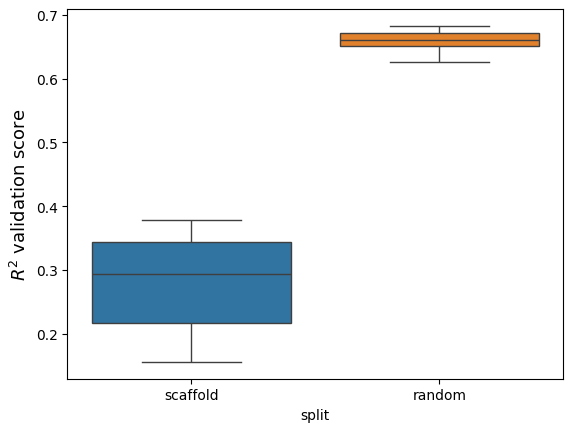

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
df_cv_compare = pd.DataFrame()

df_scaffold_cv_results = pd.DataFrame(search_scaffold.cv_results_)
df_random_cv_results =  pd.DataFrame(search_random.cv_results_)


#get the row corresponding to the best hyperparameters
scaffold_best_idx = df_scaffold_cv_results[['mean_test_score']].idxmax().values[0]
random_best_idx = df_random_cv_results[['mean_test_score']].idxmax().values[0]

#get the CV scores of the best hyperparameters
scaffold_split_cv_score = df_scaffold_cv_results.loc[scaffold_best_idx,df_scaffold_cv_results.columns.str.contains("split")]
random_split_cv_score =  df_random_cv_results.loc[random_best_idx,df_random_cv_results.columns.str.contains("split")]

#prepare dataframe for boxplot
df_cv_compare["score"] = list(scaffold_split_cv_score) + list(random_split_cv_score)
df_cv_compare["split"] = ["scaffold" for i in scaffold_split_cv_score ] + ["random" for i in random_split_cv_score ]

sns.boxplot(data=df_cv_compare, x="split", y="score",hue="split")
plt.ylabel("$R^2$ validation score",fontsize=13)
plt.show()

In [50]:
#!pip install statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd
thsd = pairwise_tukeyhsd(df_cv_compare.score, df_cv_compare.split)

In [51]:
print(thsd)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2  meandiff p-adj  lower   upper  reject
-----------------------------------------------------
random scaffold  -0.3827   0.0 -0.4249 -0.3404   True
-----------------------------------------------------


In TukeyHSD test, if **p-adj < 0.05**, there is a **statistically significant difference**. 

In real world scenario, the new compounds to be evaluated will likely contain different scaffolds from that of the training set.

Now, let's compare the model performance on unseen scaffolds, i.e. our **test set**.

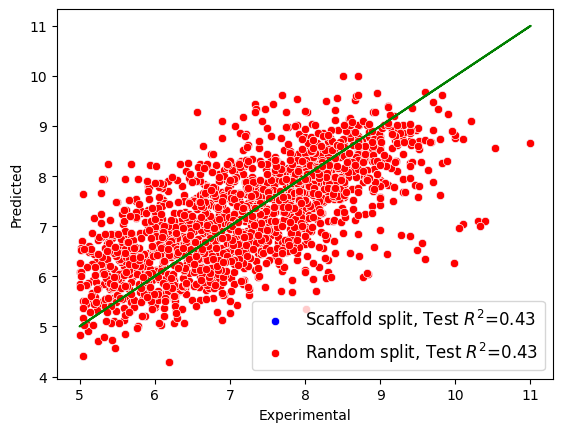

In [52]:
y_pred_random = search_random.best_estimator_.predict(x_test)
r2_random = r2_score(y_test,y_pred_random)

sns.scatterplot(x=y_test, y=y_pred_scaffold,color='b',label=f"Scaffold split, Test $R^2$={r2_scaffold:.2f}")
sns.scatterplot(x=y_test, y=y_pred_random,color='r',label=f"Random split, Test $R^2$={r2_random:.2f}")
plt.plot(y_test,y_test,color='g')

plt.xlabel("Experimental")
plt.ylabel("Predicted")
plt.legend(fontsize=12)
plt.show()

In [53]:
df_cv_test = pd.DataFrame()
df_cv_test["split type"] = ["scaffold","random"] 
df_cv_test["validation score"] = [scaffold_split_cv_score.median(),random_split_cv_score.median()]   
df_cv_test["test score"] = [r2_scaffold,r2_random]
df_cv_test

,split type,validation score,test score
0,scaffold,0.293215,0.43378
1,random,0.660820,0.43378


## Take aways

In this example, the model trained via scaffold splits tends to have better generalizability on unseen scaffolds.

Moreover, the discrepancy between the validation and test score is higher in random splits than in scaffold splits.

Based on this result, scaffold splits can potentially:
- give **a more realistic estimation of model performance than the default random splits**
- **help mitigate overfitting** during hyperparameter optimization

Although this outcome could highly depend on the data itself (as well as the arbitrary random states), this notebook shows the advantage of using scaffold splits, which has now a **convenient implementation in scikit-mol**. :)